In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# --- 1. Neural Network Definition (FIXED) ---
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.activation = nn.Tanh() # SiLU is also excellent, as we discussed
        self.layers = nn.ModuleList()
        
        # --- FIX: Removed BatchNorm1d ---
        # BatchNorm is unstable for PINN autograd
        
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

    def forward(self, x):
        for i in range(len(self.layers) - 1):
            x = self.activation(self.layers[i](x))
        # No activation on the final layer
        x = self.layers[-1](x)
        return x

In [3]:
# --- 2. The Main Physics-Informed Class ---
class BoussinesqPINN:
    def __init__(self, network, nu, P, r_integral_pts):
        self.network = network.to(device)
        self.nu = nu
        self.P = P # Store the point load
        
        # Store sorted points for surface integration
        self.r_integral_pts = r_integral_pts.to(device)
        self.z_integral_pts = torch.zeros_like(self.r_integral_pts).to(device)

        # Use a stable initial LR
        self.optimizer = torch.optim.Adam(self.network.parameters(), lr=1e-3, amsgrad=True)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=5000, 
            threshold=1e-4, min_lr=1e-7
        )

        # --- FIX: Re-balanced Loss Weights ---
        # Prioritize the "hard" constraints (BCs and Force) over the "soft" PDE.
        self.w_pde   = 1.0      
        self.w_bc    = 500.0     # Was 10.0
        self.w_force = 1000.0   # Was 100.0

    def _get_pde_residuals(self, r, z):
        """
        Computes the coupled system PDE residuals.
        """
        r.requires_grad_(True)
        z.requires_grad_(True)

        net_out = self.network(torch.cat([r, z], dim=1))
        phi, psi = net_out[:, 0:1], net_out[:, 1:2]

        # Derivatives for R1
        phi_r = torch.autograd.grad(phi, r, torch.ones_like(phi), create_graph=True)[0]
        phi_rr = torch.autograd.grad(phi_r, r, torch.ones_like(phi_r), create_graph=True)[0]
        phi_z = torch.autograd.grad(phi, z, torch.ones_like(phi), create_graph=True)[0]
        phi_zz = torch.autograd.grad(phi_z, z, torch.ones_like(phi_z), create_graph=True)[0]
        
        r_safe = torch.clamp(r, min=1e-6)
        laplacian_phi = phi_rr + (1 / r_safe) * phi_r + phi_zz
        
        # Derivatives for R2
        psi_r = torch.autograd.grad(psi, r, torch.ones_like(psi), create_graph=True)[0]
        psi_rr = torch.autograd.grad(psi_r, r, torch.ones_like(psi_r), create_graph=True)[0]
        psi_z = torch.autograd.grad(psi, z, torch.ones_like(psi), create_graph=True)[0]
        psi_zz = torch.autograd.grad(psi_z, z, torch.ones_like(psi_z), create_graph=True)[0]
        
        laplacian_psi = psi_rr + (1 / r_safe) * psi_r + psi_zz

        pde_residual_1 = laplacian_phi - psi
        pde_residual_2 = laplacian_psi

        return pde_residual_1, pde_residual_2

    def compute_stresses(self, r, z):
        """
        Computes stresses using the coupled system.
        """
        r.requires_grad_(True)
        z.requires_grad_(True)
        
        net_out = self.network(torch.cat([r, z], dim=1))
        phi, psi = net_out[:, 0:1], net_out[:, 1:2]

        phi_z = torch.autograd.grad(phi, z, torch.ones_like(phi), create_graph=True)[0]
        phi_zz = torch.autograd.grad(phi_z, z, torch.ones_like(phi_z), create_graph=True)[0]

        sigma_zz_term = (2 - self.nu) * psi - phi_zz
        sigma_zz = torch.autograd.grad(sigma_zz_term, z, torch.ones_like(sigma_zz_term), create_graph=True)[0]

        tau_rz_term = (1 - self.nu) * psi - phi_zz
        tau_rz = torch.autograd.grad(tau_rz_term, r, torch.ones_like(tau_rz_term), create_graph=True)[0]

        return sigma_zz, tau_rz

    def _get_phi_r(self, r, z):
        """Helper to get phi_r for the axis loss."""
        r.requires_grad_(True)
        z.requires_grad_(True)
        
        net_out = self.network(torch.cat([r, z], dim=1))
        phi = net_out[:, 0:1] # Just need phi
        
        phi_r = torch.autograd.grad(phi, r, torch.ones_like(phi), create_graph=True)[0]
        return phi_r
    
    Total_loss, Loss_pde, Loss_bc, Loss_force = [], [], [], []

    def loss_function(self, pde_pts, surface_pts, far_field_pts, axis_pts):
        # 1. PDE Loss (Coupled System)
        r_pde, z_pde = pde_pts[:, 0:1], pde_pts[:, 1:2]
        pde_res_1, pde_res_2 = self._get_pde_residuals(r_pde, z_pde)
        
        # r-weighting (This was a great implementation by you)
        loss_pde = torch.mean(r_pde * (pde_res_1**2)) + torch.mean(r_pde * (pde_res_2**2))

        # 2. Boundary Condition Losses
        
        # --- THE CRITICAL FIX ---
        # Surface (z=0, r > 0)
        r_surf, z_surf = surface_pts[:, 0:1], surface_pts[:, 1:2]
        _, tau_rz_surf = self.compute_stresses(r_surf, z_surf)
        # Only the shear stress (tau_rz) is zero on the surface.
        # The normal stress (sigma_zz) is governed *only* by the force integral loss.
        loss_bc_surface = torch.mean(tau_rz_surf**2)
        # ------------------------

        # Far-field stresses should be zero
        r_far, z_far = far_field_pts[:, 0:1], far_field_pts[:, 1:2]
        sigma_zz_far, tau_rz_far = self.compute_stresses(r_far, z_far)
        loss_bc_far_field = torch.mean(sigma_zz_far**2) + torch.mean(tau_rz_far**2)

        # Axisymmetry condition (d(phi)/dr = 0 at r=0)
        r_axis, z_axis = axis_pts[:, 0:1], axis_pts[:, 1:2]
        phi_r_axis = self._get_phi_r(r_axis, z_axis)
        loss_bc_axis = torch.mean(phi_r_axis**2)

        # Combine all standard BC losses
        loss_bc = loss_bc_surface + loss_bc_far_field + loss_bc_axis
        
        # 3. Point Load Integral Constraint
        sigma_zz_int, _ = self.compute_stresses(self.r_integral_pts, self.z_integral_pts)
        integrand = sigma_zz_int * (2 * np.pi * self.r_integral_pts)
        total_force = torch.trapezoid(integrand.squeeze(), self.r_integral_pts.squeeze())
        loss_force = (total_force + self.P)**2
        
        # Total weighted loss
        total_loss = (self.w_pde * loss_pde + 
                      self.w_bc * loss_bc + 
                      self.w_force * loss_force)
        
        return total_loss, loss_pde, loss_bc, loss_force

    def train(self, epochs, pde_pts, surface_pts, far_field_pts, axis_pts):
        
        for epoch in range(epochs):
            self.network.train()
            self.optimizer.zero_grad()
            
            loss, loss_pde, loss_bc, loss_force = self.loss_function(pde_pts, surface_pts, far_field_pts, axis_pts)
            
            loss.backward()
            self.optimizer.step()
            
            # Step the scheduler with the current loss
            self.scheduler.step(loss)

            #Saving losses for plotting learning curve
            self.Total_loss.append(loss.item())
            self.Loss_pde.append(loss_pde.item())
            self.Loss_bc.append(loss_bc.item())
            self.Loss_force.append(loss_force.item())
            
            if epoch % 100 == 0: # Print more often
                print(f"Epoch {epoch+1}/{epochs} -> Total Loss: {loss.item():.4e}, "
                      f"PDE: {loss_pde.item():.4e}, BC: {loss_bc.item():.4e}, Force: {loss_force.item():.4e}, "
                      f"LR: {self.optimizer.param_groups[0]['lr']:.2e}")

In [4]:
# --- 3. Main Execution Block ---
#if __name__ == '__main__':
# Problem Parameters
NU = 0.3      # Poisson's ratio
P = 1000.0     # Point load magnitude (using a larger value helps)
R_DOMAIN = 10.0  # Domain radius (Your fix was correct)
Z_DOMAIN = 10.0  # Domain depth (Your fix was correct)

# Collocation Points
N_PDE = 8000
N_BC = 1500
N_INTEGRAL = 500 # More points for the integral is good

# --- Your excellent sampling scheme (no change needed) ---
N_REGULAR = int(N_PDE * 0.6)
r_pde_reg = torch.sqrt(torch.rand(N_REGULAR, 1)) * R_DOMAIN
z_pde_reg = torch.rand(N_REGULAR, 1) * Z_DOMAIN

N_SINGULARITY = int(N_PDE * 0.25)
r_pde_sing = torch.sqrt(torch.rand(N_SINGULARITY, 1)) * (R_DOMAIN * 0.05) 
z_pde_sing = torch.rand(N_SINGULARITY, 1) * (Z_DOMAIN * 0.05)

N_SURFACE = int(N_PDE * 0.15)
r_pde_surf = torch.sqrt(torch.rand(N_SURFACE, 1)) * R_DOMAIN
z_pde_surf = torch.rand(N_SURFACE, 1) * (Z_DOMAIN * 0.1)

r_pde = torch.cat([r_pde_reg, r_pde_sing, r_pde_surf], dim=0)
z_pde = torch.cat([z_pde_reg, z_pde_sing, z_pde_surf], dim=0)
pde_points = torch.cat([r_pde, z_pde], dim=1).to(device)

print(f"Total collocation points: {pde_points.shape[0]}")

# Boundary points
r_surface = torch.rand(N_BC, 1) * R_DOMAIN
r_surface[r_surface == 0] = 1e-8
surface_points = torch.cat([r_surface, torch.zeros_like(r_surface)], dim=1).to(device)

r_far_vert  = R_DOMAIN * torch.ones(N_BC // 2, 1)
z_far_vert  = Z_DOMAIN * torch.rand(N_BC // 2, 1)
r_far_horiz = R_DOMAIN * torch.rand(N_BC // 2, 1)
z_far_horiz = Z_DOMAIN * torch.ones(N_BC // 2, 1)
far_field_points = torch.cat([
    torch.cat([r_far_vert, z_far_vert], dim=1),
    torch.cat([r_far_horiz, z_far_horiz], dim=1)
], dim=0).to(device)

r_axis = torch.full((N_BC, 1), 1e-8)
z_axis = torch.rand(N_BC, 1) * Z_DOMAIN
axis_points = torch.cat([r_axis, z_axis], dim=1).to(device)

r_integral_pts = torch.linspace(1e-8, R_DOMAIN, N_INTEGRAL).view(-1, 1).to(device)

# Initialize model and train
layers = [2, 75, 75, 75, 75, 75, 2] # Your network is good
pinn_net = PINN(layers)

boussinesq_solver = BoussinesqPINN(
    pinn_net, 
    nu=NU, 
    P=P, 
    r_integral_pts=r_integral_pts
)

print("--- Starting Training ---")
boussinesq_solver.train(100_000, pde_points, surface_points, far_field_points, axis_points) # Train for longer
print("--- Training Complete ---")

torch.save(boussinesq_solver.network.state_dict(), 'boussinesq_model_fixed.pth')
print("Model saved to boussinesq_model_fixed.pth")

Total collocation points: 8000
--- Starting Training ---
Epoch 1/100000 -> Total Loss: 9.7771e+08, PDE: 4.8699e-03, BC: 4.7997e-04, Force: 9.7771e+05, LR: 1.00e-03
Epoch 101/100000 -> Total Loss: 2.9921e+03, PDE: 3.5016e+01, BC: 1.9736e-01, Force: 2.8584e+00, LR: 1.00e-03
Epoch 201/100000 -> Total Loss: 1.3079e+02, PDE: 3.2332e+01, BC: 1.9688e-01, Force: 1.8254e-05, LR: 1.00e-03
Epoch 301/100000 -> Total Loss: 1.2837e+02, PDE: 2.9934e+01, BC: 1.9687e-01, Force: 1.4901e-08, LR: 1.00e-03
Epoch 401/100000 -> Total Loss: 1.2615e+02, PDE: 2.7716e+01, BC: 1.9686e-01, Force: 1.4901e-08, LR: 1.00e-03
Epoch 501/100000 -> Total Loss: 1.2408e+02, PDE: 2.5650e+01, BC: 1.9686e-01, Force: 3.7253e-09, LR: 1.00e-03
Epoch 601/100000 -> Total Loss: 1.2215e+02, PDE: 2.3723e+01, BC: 1.9685e-01, Force: 1.4901e-08, LR: 1.00e-03
Epoch 701/100000 -> Total Loss: 1.2035e+02, PDE: 2.1923e+01, BC: 1.9684e-01, Force: 1.4901e-08, LR: 1.00e-03
Epoch 801/100000 -> Total Loss: 1.1866e+02, PDE: 2.0243e+01, BC: 1.9684e-


--- Plotting Learning Curve ---


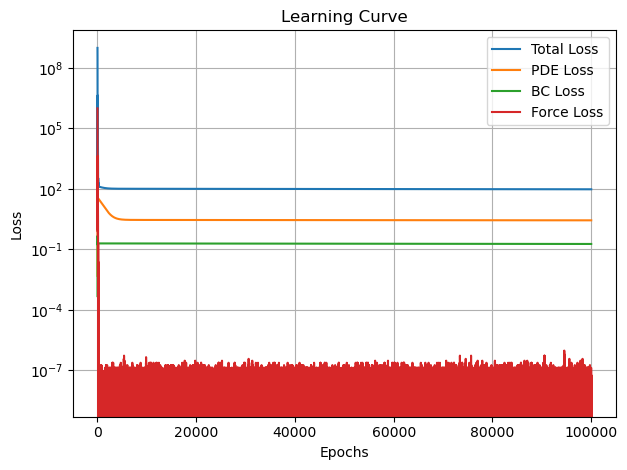

In [5]:
# --- 4. Verification and Plotting  ---

print("\n--- Plotting Learning Curve ---")

plt.plot(boussinesq_solver.Total_loss, label='Total Loss')
plt.plot(boussinesq_solver.Loss_pde, label='PDE Loss')
plt.plot(boussinesq_solver.Loss_bc, label='BC Loss')
plt.plot(boussinesq_solver.Loss_force, label='Force Loss')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


--- Verifying Results ---


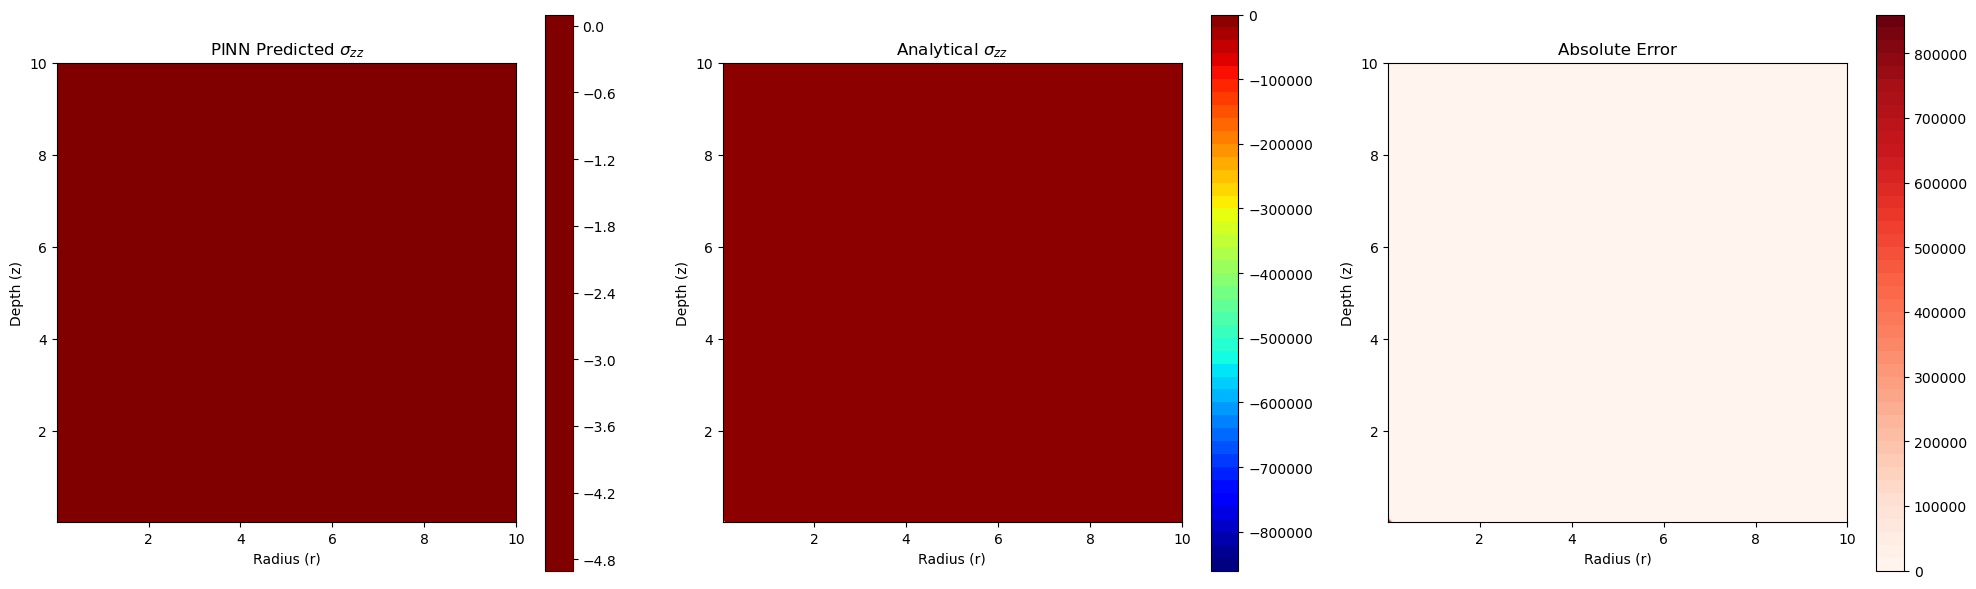

In [6]:
print("\n--- Verifying Results ---")

grid_res = 100
r_plot = np.linspace(0.01, R_DOMAIN, grid_res)
z_plot = np.linspace(0.01, Z_DOMAIN, grid_res)
R_grid, Z_grid = np.meshgrid(r_plot, z_plot)

r_tensor = torch.tensor(R_grid.flatten(), dtype=torch.float32).view(-1, 1).to(device)
z_tensor = torch.tensor(Z_grid.flatten(), dtype=torch.float32).view(-1, 1).to(device)

pinn_net.eval()
r_tensor.requires_grad_(True)
z_tensor.requires_grad_(True)
sigma_zz_pred, _ = boussinesq_solver.compute_stresses(r_tensor, z_tensor)
sigma_zz_pinn = sigma_zz_pred.cpu().detach().numpy().reshape(R_grid.shape)

def analytical_sigma_zz(r, z, P):
    return (-3 * P / (2 * np.pi)) * (z**3) / ((r**2 + z**2)**(5/2))

sigma_zz_analytical = analytical_sigma_zz(R_grid, Z_grid, P)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

vmin = sigma_zz_analytical.min()
vmax = 0 

c1 = axes[0].contourf(R_grid, Z_grid, sigma_zz_pinn, levels=50, cmap='jet', vmin=vmin, vmax=vmax)
axes[0].set_title("PINN Predicted $\\sigma_{zz}$")
axes[0].set_xlabel("Radius (r)")
axes[0].set_ylabel("Depth (z)")
fig.colorbar(c1, ax=axes[0])
axes[0].set_aspect('equal')

c2 = axes[1].contourf(R_grid, Z_grid, sigma_zz_analytical, levels=50, cmap='jet', vmin=vmin, vmax=vmax)
axes[1].set_title("Analytical $\\sigma_{zz}$")
axes[1].set_xlabel("Radius (r)")
axes[1].set_ylabel("Depth (z)")
fig.colorbar(c2, ax=axes[1])
axes[1].set_aspect('equal')

error = np.abs(sigma_zz_pinn - sigma_zz_analytical)
c3 = axes[2].contourf(R_grid, Z_grid, error, levels=50, cmap='Reds')
axes[2].set_title("Absolute Error")
axes[2].set_xlabel("Radius (r)")
axes[2].set_ylabel("Depth (z)")
fig.colorbar(c3, ax=axes[2])
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()